In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from joblib import load

In [2]:
test_df = pd.read_parquet("../predict_ridership/output/cta_ridership_test.parquet")
mod_rf = load("../predict_ridership/output/mod_rf.joblib")

In [3]:
y_test = test_df["rides"]
X_test = test_df.drop(columns=["rides"]).values

y_pred_rf = mod_rf.predict(X_test)

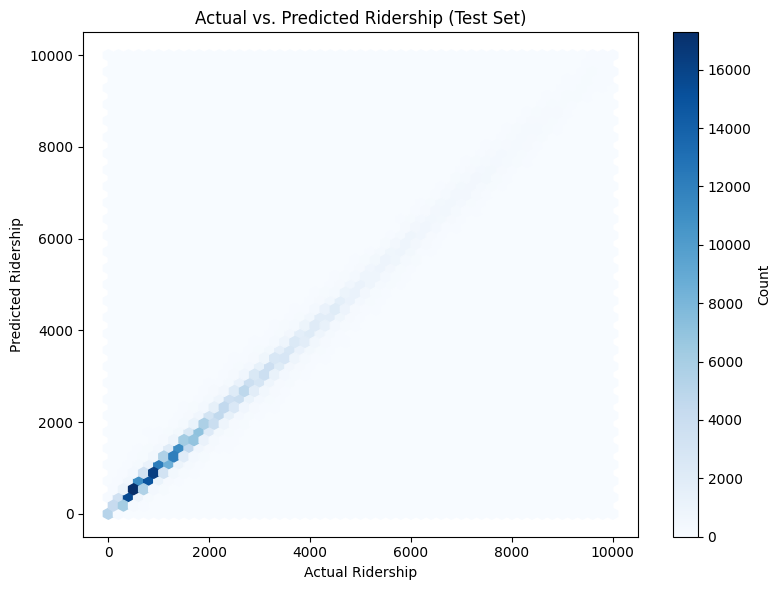

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

hb = ax.hexbin(y_test, y_pred_rf, gridsize=50, cmap="Blues", extent=(0, 1e4, 0, 1e4))
fig.colorbar(hb, ax=ax, label="Count")
ax.set_xlabel("Actual Ridership")
ax.set_ylabel("Predicted Ridership")
ax.set_title("Actual vs. Predicted Ridership (Test Set)")

plt.tight_layout()
plt.show()